In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import HTML
import random

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import torch
from transformers import AutoTokenizer, AutoModel
import fasttext.util
import pickle
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import randint, uniform
from sklearn.metrics import roc_curve, auc

# Настройки
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
random.seed(42)
np.random.seed(42)

In [2]:
# Импортируем данные
file_id = '1H3hByerVsbJd-mR7I8LK60RpL_87sNza'
url = f'https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t'
data = pd.read_csv(url)
data.head()

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,adj_count,vocative,expr_punct
0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.67,False,False,False,False,False,False,0,0,0,True,False
1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжать рабочий дом снитенко гомолыс...,я сегодня проезжала по рабочей и между домами ...,180,28,5.21,True,False,False,False,False,False,0,0,3,False,False
2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.78,True,False,False,False,False,False,0,0,8,False,True
3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.70,True,False,False,False,False,False,0,0,0,False,True
4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородок получить,а когда мы статус агрогородка получили,39,6,5.50,True,False,False,False,False,False,0,0,0,False,False


In [3]:
df = data.copy()
df = df[['label', 'comment', 'cleaned_comment', 'comment_without_punct']]
df['cleaned_comment'] = np.where(df['cleaned_comment'].isna(), df['comment_without_punct'], df['cleaned_comment'])

In [4]:
# Разобьем данные на X и y
X = df['cleaned_comment'].astype(str).tolist()
y = df['label']

In [5]:
# Для моделей будем использовать численные классы
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Classes:', list(le.classes_))

# Разделим выборку на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_enc
)

print('Train size:', len(X_train), 'Test size:', len(X_test))

Classes: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']
Train size: 198624 Test size: 49657


In [6]:
# Векторизация FastText

# Скачиваем модель fasttext
fasttext.util.download_model('ru', if_exists='ignore')
ft = fasttext.load_model('cc.ru.300.bin')

# Проверим размер файла
file_size = os.path.getsize('cc.ru.300.bin') / (1024 ** 3)
print(f'Размер файла: {file_size:.2f} GB')

def fasttext_embeddings(comments):
    embeddings = []
    for comment in comments:
        words = comment.split()
        # на случай пустых строк
        if not words:
            embeddings.append(np.zeros(300))
            continue

        vectors = [ft.get_word_vector(word) for word in words if word in ft.words]

        if vectors:
            embeddings.append(np.mean(vectors, axis=0))
        else:
            embeddings.append(np.zeros(300))
    return embeddings

def process_embedding(comments, batch_size, desc):
    result = []
    for i in tqdm(range(0, len(comments), batch_size), desc=desc):
        batch_comments = comments[i:i + batch_size]
        batch_embeddings = fasttext_embeddings(batch_comments)
        result.extend(batch_embeddings)

    return np.array(result)

# Найдем эмбеддинги
X_vectors_train = process_embedding(X_train, batch_size=500, desc='Векторизация train')
X_vectors_test = process_embedding(X_test, batch_size=1000, desc='Векторизация test')

print('X_vectors_train:', X_vectors_train.shape)
print('X_vectors_test:', X_vectors_test.shape)

Размер файла: 6.76 GB


Векторизация train:   0%|          | 0/398 [00:00<?, ?it/s]

Векторизация test:   0%|          | 0/50 [00:00<?, ?it/s]

X_vectors_train: (198624, 300)
X_vectors_test: (49657, 300)


## Decision Tree на FastText эмбеддингах

In [7]:
# 1) Baseline

dt_clf = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced',
    max_depth=40,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_clf.fit(X_vectors_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [8]:
# Предсказываем класс на тестовых и трейновых данных
dt_pred = dt_clf.predict(X_vectors_test)
dt_pred_proba = dt_clf.predict_proba(X_vectors_test)
dt_pred_train = dt_clf.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, dt_pred_train, average="macro"):.4f}')

F1 (macro) на train выборке: 0.8130


In [9]:
# Проверим метрики качества
def quality_metrics(y_true, y_pred, model_name):

    print(f'Метрики качества {model_name}')
    print('-' * 40)
    
    display(HTML(f'<b>F1 (macro):  {f1_score(y_true, y_pred, average="macro"):.4f}</b>'))
    print(f'Accuracy:    {(y_pred == y_true).mean():.0%}')
    print(f'Precision:   {precision_score(y_true, y_pred, average="macro"):.3f}')
    print(f'Recall:      {recall_score(y_true, y_pred, average="macro"):.3f}')

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=le.classes_))


quality_metrics(y_test, dt_pred, 'FastText + Decision Tree Baseline')

Метрики качества FastText + Decision Tree Baseline
----------------------------------------


Accuracy:    78%
Precision:   0.470
Recall:      0.583

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.37      0.55      0.44      5713
      NORMAL       0.94      0.83      0.88     40736
   OBSCENITY       0.26      0.47      0.34       852
      THREAT       0.31      0.48      0.37      2356

    accuracy                           0.78     49657
   macro avg       0.47      0.58      0.51     49657
weighted avg       0.83      0.78      0.80     49657



In [11]:
# 2) С подбором гиперпараметров с помощью GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")

param_grid_dt = {
    "max_depth": [5, 10, 20, 30, None],
    "min_samples_split": [5, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}

gs_dt = GridSearchCV(
    dt,
    param_grid_dt,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

gs_dt.fit(X_vectors_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [12]:
print("Best params:", gs_dt.best_params_)
print("Best CV f1_macro:", gs_dt.best_score_)

best_dt = gs_dt.best_estimator_

best_dt_pred = best_dt.predict(X_vectors_test)
best_dt_pred_proba = best_dt.predict_proba(X_vectors_test)
best_dt_pred_train = best_dt.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, best_dt_pred_train, average="macro"):.4f}')

Best params: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV f1_macro: 0.5393684861268186
F1 (macro) на train выборке: 0.8873


In [13]:
quality_metrics(y_test, best_dt_pred, 'FastText + Decision Tree GridSearchCV')

Метрики качества FastText + Decision Tree GridSearchCV
----------------------------------------


Accuracy:    81%
Precision:   0.506
Recall:      0.583

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.42      0.50      0.46      5713
      NORMAL       0.93      0.88      0.90     40736
   OBSCENITY       0.31      0.48      0.38       852
      THREAT       0.37      0.47      0.41      2356

    accuracy                           0.81     49657
   macro avg       0.51      0.58      0.54     49657
weighted avg       0.83      0.81      0.82     49657



## LightGBM на FastText эмбеддингах

In [14]:
# 1) Baseline
lgbm_clf = LGBMClassifier(
    objective='multiclass',
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_clf.fit(X_vectors_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 198624, number of used features: 300
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,800
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
lgbm_pred = lgbm_clf.predict(X_vectors_test)
lgbm_pred_proba = lgbm_clf.predict_proba(X_vectors_test)
lgbm_pred_train = lgbm_clf.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, lgbm_pred_train, average="macro"):.4f}')

F1 (macro) на train выборке: 0.9473


In [16]:
quality_metrics(y_test, lgbm_pred, 'FastText + LightGBM Baseline')

Метрики качества FastText + LightGBM Baseline
----------------------------------------


Accuracy:    91%
Precision:   0.742
Recall:      0.750

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.65      0.76      0.70      5713
      NORMAL       0.97      0.95      0.96     40736
   OBSCENITY       0.63      0.62      0.63       852
      THREAT       0.71      0.68      0.70      2356

    accuracy                           0.91     49657
   macro avg       0.74      0.75      0.74     49657
weighted avg       0.91      0.91      0.91     49657



In [18]:
# 2) С подбором гиперпараметров с помощью RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm = LGBMClassifier(
    objective="multiclass",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

param_dist = {
    "n_estimators": randint(200, 1200),
    "learning_rate": uniform(0.01, 0.15),
    "num_leaves": randint(15, 127),
    "min_child_samples": randint(5, 80),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0.0, 2.0),
    "reg_lambda": uniform(0.0, 5.0),
}

rs_lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rs_lgbm.fit(X_vectors_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.499757 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.415229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 158899, number of used features: 300
[LightGBM] [Info] Number of data points in the train set: 158899, number of used features: 300
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x51359dbf0>, 'learning_rate': <scipy.stats....t 0x5228f5c70>, 'min_child_samples': <scipy.stats....t 0x5228f5d90>, 'n_estimators': <scipy.stats....t 0x5228e4770>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`U

In [19]:
print("Best params:", rs_lgbm.best_params_)
print("Best CV f1_macro:", rs_lgbm.best_score_)

best_lgbm = rs_lgbm.best_estimator_

best_lgbm_pred = best_lgbm.predict(X_vectors_test)
best_lgbm_pred_proba = best_lgbm.predict_proba(X_vectors_test)
best_lgbm_pred_train = best_lgbm.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, best_lgbm_pred_train, average="macro"):.4f}')

Best params: {'colsample_bytree': np.float64(0.7975182385457563), 'learning_rate': np.float64(0.0884099244072991), 'min_child_samples': 19, 'n_estimators': 1057, 'num_leaves': 56, 'reg_alpha': np.float64(0.8786730037315402), 'reg_lambda': np.float64(1.008596011676981), 'subsample': np.float64(0.9583054382694077)}
Best CV f1_macro: 0.7594157127684917
F1 (macro) на train выборке: 0.9587


In [20]:
quality_metrics(y_test, best_lgbm_pred, 'FastText + LightGBM RandomizedSearchCV')

Метрики качества FastText + LightGBM RandomizedSearchCV
----------------------------------------


Accuracy:    91%
Precision:   0.756
Recall:      0.748

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.68      0.74      0.71      5713
      NORMAL       0.96      0.96      0.96     40736
   OBSCENITY       0.64      0.62      0.63       852
      THREAT       0.74      0.67      0.70      2356

    accuracy                           0.91     49657
   macro avg       0.76      0.75      0.75     49657
weighted avg       0.91      0.91      0.91     49657



## Визуализация

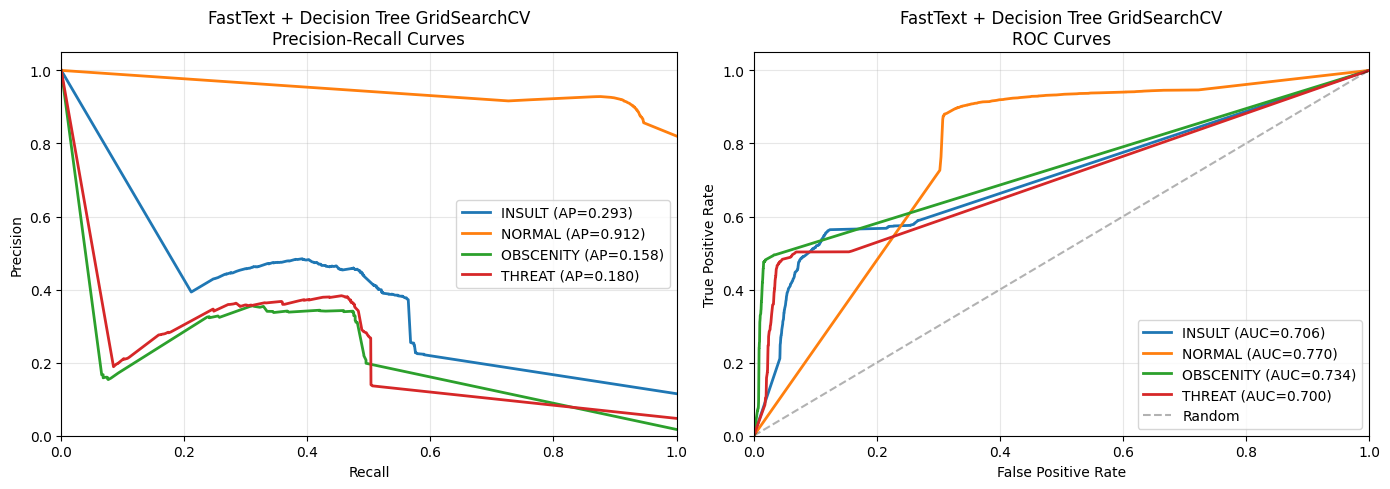


FastText + Decision Tree GridSearchCV - ROC Macro AUC: 0.7276

Метрики по классам:
  INSULT: AP=0.2933, AUC=0.7064
  NORMAL: AP=0.9124, AUC=0.7699
  OBSCENITY: AP=0.1579, AUC=0.7339
  THREAT: AP=0.1802, AUC=0.7001


In [26]:
from sklearn.metrics import roc_auc_score
def plot_pr_and_roc(model, name, X, y, label_encoder, figsize=(14, 5)):

    class_names = label_encoder.classes_
    classes = np.sort(np.unique(y))
    y_bin = label_binarize(y, classes=classes)
    n_classes = len(classes)
    probs = model.predict_proba(X)
    
    fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=figsize)
    
    # ========== PR кривая ==========
    for i, cls in enumerate(classes):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
        ap = average_precision_score(y_bin[:, i], probs[:, i])
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ax_pr.plot(rec, prec, lw=2, label=f'{class_name} (AP={ap:.3f})')
    
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'{name}\nPrecision-Recall Curves')
    ax_pr.legend(loc='best')
    ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    
    # ========== ROC кривая ==========
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ax_roc.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={roc_auc:.3f})')
    
    
    # Macro-average для ROC
    roc_auc_macro = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
    
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{name}\nROC Curves')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(True, alpha=0.3)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{name} - ROC Macro AUC: {roc_auc_macro:.4f}")
    
    print("\nМетрики по классам:")
    for i, cls in enumerate(classes):
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ap = average_precision_score(y_bin[:, i], probs[:, i])
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        print(f"  {class_name}: AP={ap:.4f}, AUC={roc_auc:.4f}")


# 1) FastText + Decision Tree GridSearchCV
plot_pr_and_roc(
    model=best_dt,
    name='FastText + Decision Tree GridSearchCV',
    X=X_vectors_test,
    y=y_test,
    label_encoder=le
)

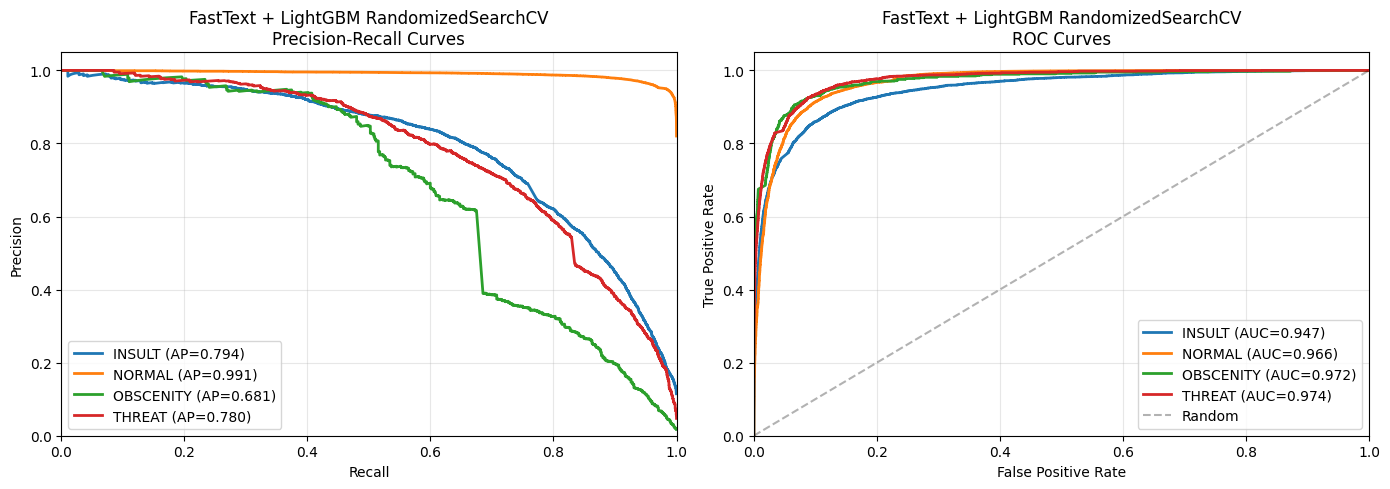


FastText + LightGBM RandomizedSearchCV - ROC Macro AUC: 0.9649

Метрики по классам:
  INSULT: AP=0.7940, AUC=0.9473
  NORMAL: AP=0.9909, AUC=0.9663
  OBSCENITY: AP=0.6814, AUC=0.9717
  THREAT: AP=0.7803, AUC=0.9744


In [27]:
# 2) FastText + LightGBM RandomizedSearchCV
plot_pr_and_roc(
    model=best_lgbm,
    name='FastText + LightGBM RandomizedSearchCV',
    X=X_vectors_test,
    y=y_test,
    label_encoder=le
)